# Experiment A - MPJPE vs network_period (Dataset-level)

Loads all generated OpenPose CSVs across all sequences and computes:
- per-sequence MPJPE
- dataset-level MPJPE (weighted by number of frames)

Outputs:
- `results/summary/mpjpe_per_sequence.csv`
- `results/summary/mpjpe_table.csv`
- `plots/mpjpe_vs_network_period.png`
- `plots/mpjpe_vs_detection_rate.png`

Note: OpenPose predictions are logged at ~50Hz while the ground truth skeletons are sampled at 200Hz; we interpolate the GT timestamps to match each prediction sample before computing MPJPE.

In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets.utils import constants as ds_constants, parsing as ds_parsing


In [9]:
EXP_DIR = Path('/home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period')
RAW_DIR = EXP_DIR / 'results' / 'raw'
SUMMARY_DIR = EXP_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DIR / 'plots'

MP4_ROOT = Path('/data/moveEnet_test/mp4')
GT_ROOT = Path('/data/new_scarfGNN_full/raw')

SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

period_tokens = ["0.02", "0.05", "0.1", "0.2", "0.5"]
period_values = [float(x) for x in period_tokens]

print('MP4_ROOT:', MP4_ROOT)
print('GT_ROOT:', GT_ROOT)
print('RAW_DIR:', RAW_DIR)
print('Periods:', period_values)

MP4_ROOT: /data/moveEnet_test/mp4
GT_ROOT: /data/new_scarfGNN_full/raw
RAW_DIR: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/results/raw
Periods: [0.02, 0.05, 0.1, 0.2, 0.5]


In [10]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

def period_to_tag(period_token: str) -> str:
    """Convert period string to filename-safe tag (e.g., '0.02' -> '0p02')"""
    return period_token.replace('.', 'p')

def tag_to_period(tag: str) -> float:
    """Convert filename tag back to period value (e.g., '0p02' -> 0.02)"""
    return float(tag.replace('p', '.'))

def load_pred_eval_csv(csv_path: Path):
    """Load prediction CSV file and extract timestamps + joint coordinates.

    CSV format (prediction-export format): [timestamp, latency, joint0_x, joint0_y, ..., joint12_x, joint12_y]
    Returns: (timestamps, joints_array[N_frames, 13_joints, 2_coords])
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints

def extract_metadata_from_name(csv_path: Path):
    """Parse CSV filename to extract experiment metadata.

    Expected format: 'sequence__openpose_np_period.csv'
    Returns: (sequence_key, method_name, network_period_seconds)
    """
    name = csv_path.name
    m = re.match(r'(.+)__openpose_np_(\d+p\d+|\d+)\.csv$', name)
    if not m:
        raise ValueError(f'Unrecognized filename format: {name}')
    seq_key, np_tag = m.groups()
    method = 'OpenPose'
    network_period_s = tag_to_period(np_tag)
    return seq_key, method, network_period_s

def gt_path_from_seq_key(seq_key: str):
    """Construct ground truth skeleton file path from sequence key (RAW dataset).

    Sequence keys encode the MP4-relative path with '/' replaced by '__'.
    """
    rel = seq_key.replace('__', '/') if '__' in seq_key else seq_key
    return GT_ROOT / rel / 'ch0GT200Hzskeleton' / 'data.log'

def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """Interpolate GT joints to prediction timestamps."""

    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))
    joints_gt = np.zeros((len(ts_pred), len(joint_names), 2), dtype=np.float64)

    for j, joint in enumerate(joint_names):

        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt

In [11]:
csv_files = sorted(RAW_DIR.glob('np_*/*.csv'))
print(f'Found {len(csv_files)} prediction CSV files')
if len(csv_files) == 0:
    raise RuntimeError('No CSV files found. Run OP_run_experiment_a.sh first.')

gt_cache = {}
rows = []

for csv_path in csv_files:
    seq_key, method, network_period_s = extract_metadata_from_name(csv_path)

    gt_path = gt_path_from_seq_key(seq_key)
    if not gt_path.exists():
        print(f'Skipping (missing GT): {gt_path}')
        continue

    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    err = np.linalg.norm(joints_pred - joints_gt, axis=2)
    per_joint = err.mean(axis=0)
    mpjpe_px = float(per_joint.mean())

    n_samples = int(err.shape[0])
    rows.append({
        'sequence': seq_key,
        'method': method,
        'network_period_s': network_period_s,
        'detection_rate_hz': 1.0 / network_period_s,
        'n_samples': n_samples,
        'sum_err_px': float(err.sum()),
        'n_points': int(err.size),
        'mpjpe_px': mpjpe_px,
        **{f'mpjpe_{joint}': float(per_joint[i]) for i, joint in enumerate(joint_names)}
    })

df_seq = pd.DataFrame(rows).sort_values(['network_period_s', 'sequence', 'method']).reset_index(drop=True)
print('Per-sequence rows:', len(df_seq))

hidden_cols = ['n_samples', 'sum_err_px', 'n_points']
visible_df = df_seq.drop(columns=hidden_cols, errors='ignore')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(visible_df)

Found 75 prediction CSV files
Per-sequence rows: 75


,sequence,method,network_period_s,detection_rate_hz,mpjpe_px,mpjpe_head,mpjpe_shoulder_right,mpjpe_shoulder_left,mpjpe_elbow_right,mpjpe_elbow_left,mpjpe_hip_left,mpjpe_hip_right,mpjpe_wrist_right,mpjpe_wrist_left,mpjpe_knee_right,mpjpe_knee_left,mpjpe_ankle_right,mpjpe_ankle_left
0,cam2_S1_Directions,OpenPose,0.02,50.0,6.762542,12.025039,4.476501,2.720835,5.419977,6.714818,10.385360,9.664762,5.173517,5.413613,3.974752,4.401148,7.310219,10.232500
1,cam2_S1_Discussion,OpenPose,0.02,50.0,6.391666,9.956533,4.100665,2.644580,4.127445,6.759850,9.402347,8.948460,5.786107,7.573400,3.990219,4.791843,6.599274,8.410937
2,cam2_S1_Eating,OpenPose,0.02,50.0,9.782551,26.008262,6.064718,3.003339,6.606159,7.000580,10.697966,8.932249,21.132477,12.995529,3.536158,6.827463,4.612314,9.755943
3,cam2_S1_Greeting,OpenPose,0.02,50.0,6.857519,11.603784,4.742177,3.398038,4.622300,6.216133,10.877261,9.647188,6.439649,9.071896,3.986916,4.660114,5.987775,7.894514
4,cam2_S1_Phoning,OpenPose,0.02,50.0,8.885110,18.757428,7.397706,4.996673,6.155030,5.907729,10.503040,10.228307,11.068837,11.489337,4.169187,5.114263,7.659516,12.059378
5,cam2_S1_Posing,OpenPose,0.02,50.0,6.406857,9.921264,6.847299,4.496340,4.800994,5.127578,10.739666,9.392553,3.663079,5.573554,4.046930,3.743387,5.383322,9.553181
6,cam2_S1_Purchases,OpenPose,0.02,50.0,13.381376,31.709562,7.127508,3.565763,18.775379,8.571800,15.568104,16.114089,37.065513,5.956949,4.863622,6.327935,6.837555,11.474112
7,cam2_S1_SittingDown,OpenPose,0.02,50.0,25.322766,10.556320,6.296218,4.452883,39.326357,6.178077,14.196171,10.603066,165.904405,7.886086,7.484535,7.931229,31.386552,16.994064
8,cam2_S1_Sitting_1,OpenPose,0.02,50.0,7.894816,10.671431,7.098607,3.376925,4.419920,6.658130,12.660500,9.433608,6.408236,7.451059,4.827157,8.250541,7.689288,13.687209
9,cam2_S1_Smoking,OpenPose,0.02,50.0,11.998483,16.793960,6.122881,3.750556,20.049100,7.299428,8.748035,8.323933,46.375934,7.842864,3.897024,4.774720,9.380594,12.621249


In [12]:
if len(df_seq) == 0:
    raise RuntimeError('No valid sequence rows to aggregate.')

# Dataset-level aggregation (OpenPose only)
agg = (
    df_seq.groupby(['network_period_s', 'detection_rate_hz', 'method'], as_index=False)
    .agg(sum_err_px=('sum_err_px', 'sum'), n_points=('n_points', 'sum'), n_samples=('n_samples', 'sum'))
    )
agg['mpjpe_px'] = agg['sum_err_px'] / agg['n_points']
df_table = agg.sort_values(['network_period_s', 'method']).reset_index(drop=True)

per_seq_path = SUMMARY_DIR / 'mpjpe_per_sequence.csv'
table_path = SUMMARY_DIR / 'mpjpe_table.csv'
df_seq.to_csv(per_seq_path, index=False)
df_table.to_csv(table_path, index=False)

print('Saved:', per_seq_path)
print('Saved:', table_path)

pivot = df_table.pivot(index=['network_period_s', 'detection_rate_hz'], columns='method', values='mpjpe_px').reset_index()
pivot.columns.name = None
display(pivot)

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/results/summary/mpjpe_per_sequence.csv
Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/results/summary/mpjpe_table.csv


,network_period_s,detection_rate_hz,OpenPose
0,0.02,50.0,11.325423
1,0.05,20.0,11.489577
2,0.10,10.0,11.868223
3,0.20,5.0,13.042950
4,0.50,2.0,16.467146


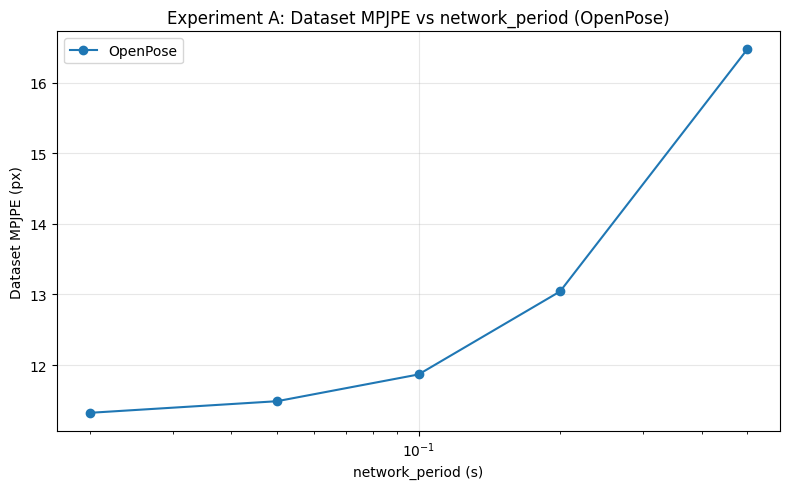

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/plots/mpjpe_vs_network_period.png


In [13]:
plt.figure(figsize=(8, 5))
method = 'OpenPose'
d = df_table[df_table['method'] == method].sort_values('network_period_s')
if len(d) > 0:
    plt.plot(d['network_period_s'], d['mpjpe_px'], marker='o', label=method)

plt.xscale('log')
plt.xlabel('network_period (s)')
plt.ylabel('Dataset MPJPE (px)')
plt.title('Experiment A: Dataset MPJPE vs network_period (OpenPose)')
plt.grid(True, alpha=0.3)
plt.legend()
plot1 = PLOTS_DIR / 'mpjpe_vs_network_period.png'
plt.tight_layout()
plt.savefig(plot1, dpi=180)
plt.show()
print('Saved:', plot1)

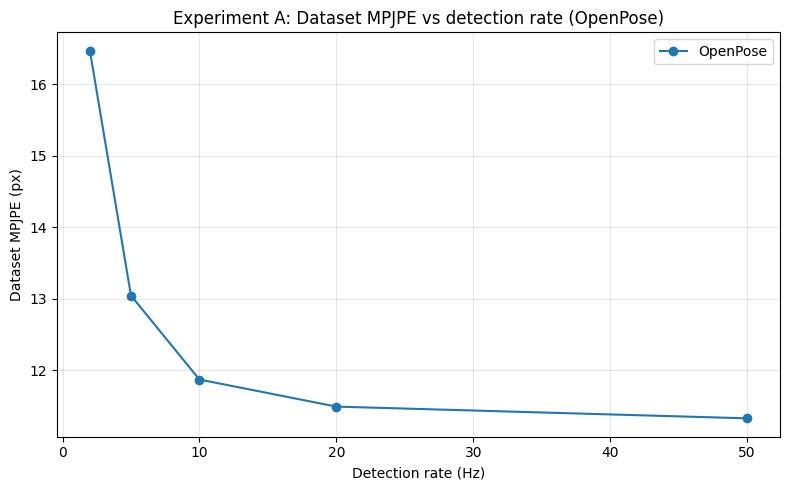

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/plots/mpjpe_vs_detection_rate.png


In [14]:
plt.figure(figsize=(8, 5))
method = 'OpenPose'
d = df_table[df_table['method'] == method].sort_values('detection_rate_hz')
if len(d) > 0:
    plt.plot(d['detection_rate_hz'], d['mpjpe_px'], marker='o', label=method)

plt.xlabel('Detection rate (Hz)')
plt.ylabel('Dataset MPJPE (px)')
plt.title('Experiment A: Dataset MPJPE vs detection rate (OpenPose)')
plt.grid(True, alpha=0.3)
plt.legend()
plot2 = PLOTS_DIR / 'mpjpe_vs_detection_rate.png'
plt.tight_layout()
plt.savefig(plot2, dpi=180)
plt.show()
print('Saved:', plot2)